In [1]:
from pathlib import Path
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import ExpPatternCompletionModel, BinaryPatternCompletionModel
from probcs.experiment_running.exc_experiment import center_surround_experiment, create_stimuli
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images, get_excitatory_images
from probcs.utils.plotting import plot_posterior
from probcs.utils.plotting import plot_posterior_binary

seed = 42
rng = np.random.default_rng(seed)

In [2]:
basepath = Path("/src/project/data/experiment")
patterns_path = basepath / "custom_centered_exc_crops.npy"
patterns = np.load(patterns_path)
patterns = patterns - patterns.mean(axis=0)
vmin = patterns.min()
vmax = patterns.max()
patterns = patterns[:3]

In [3]:
G_dim = len(patterns)
G_prob = 0.5
I_sigma = 100
patterns_offset = 0

g_x_mapping = None

G_visual_nrows = G_dim
G_visual_ncols = 1
x_visual_nrows = G_dim
x_visual_ncols = 9
n_tune = 300
n_draws = 300
n_chains = 4
n_cores = 4

mapping = np.zeros((G_dim*9, G_dim)) + 0.05
for j in range(0, G_dim*9, G_dim):
    for i in range(G_dim):
        mapping[i + j, i] = 0.8

In [4]:
model = BinaryPatternCompletionModel(
    patterns=patterns,
    G_prob=G_prob,
    I_sigma=I_sigma,
    patterns_offset=patterns_offset,
    g_x_mapping=mapping
)

In [5]:
cossim = cosine_similarity(model.patterns.reshape(model.patterns.shape[0], -1))

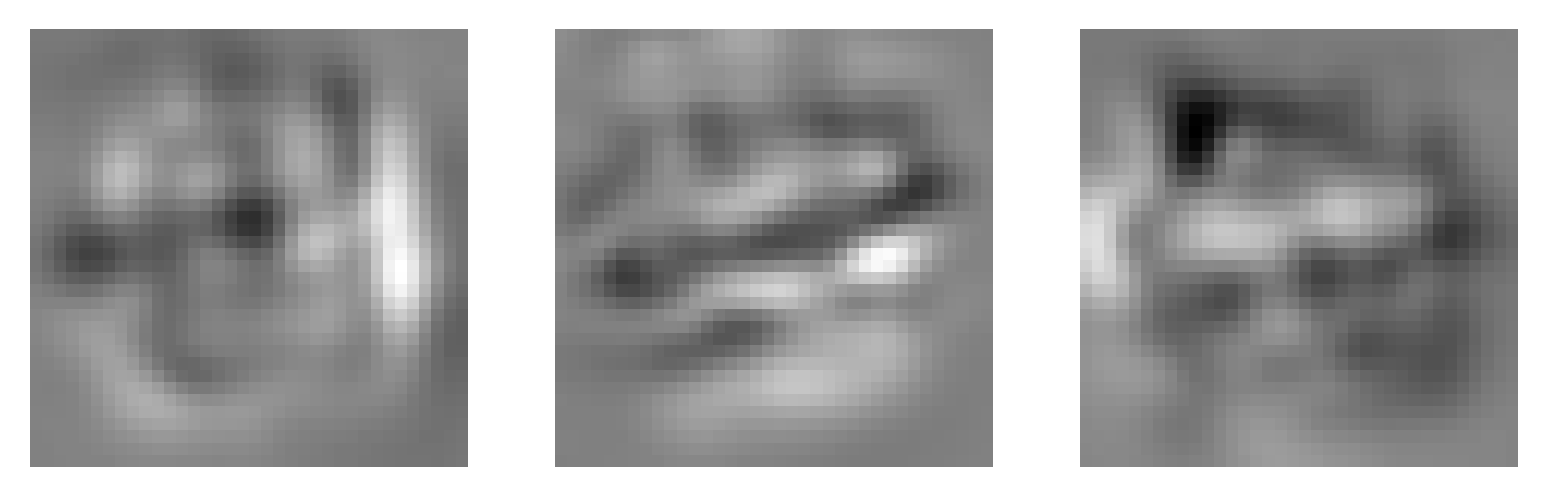

In [6]:
fig, axs = plt.subplots(1, G_dim, dpi=300)
for ax, pattern in zip(axs.flatten(), patterns):
    ax.imshow(pattern, cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

Text(0.5, 1.0, 'Cos sim between assigned Gs')

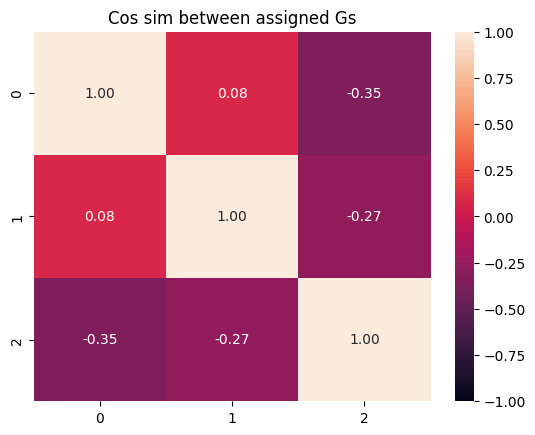

In [7]:
fig, ax = plt.subplots(dpi=100)
sns.heatmap(cossim, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Cos sim between assigned Gs")

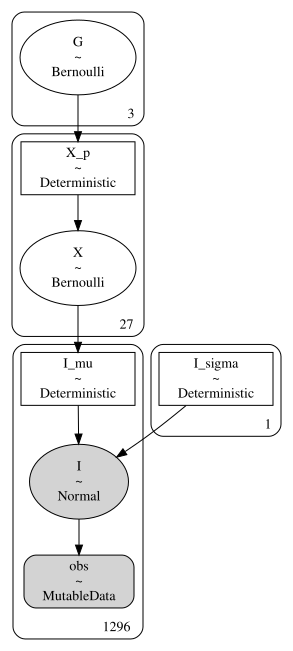

In [8]:
pm.model_to_graphviz(model.prob_model)

In [9]:
prior_samples_dict = model.sample_prior_predictive(n_samples=100, random_seed=1)

Sampling: [G, I, X]


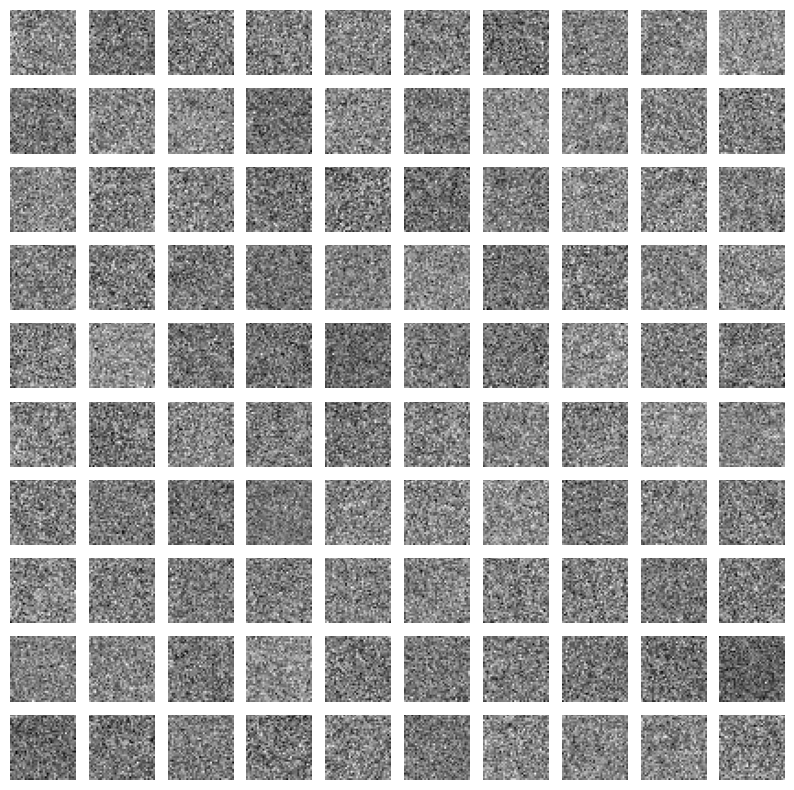

In [10]:
fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(prior_samples_dict["I"][idx], cmap="gray")
    ax.axis("off")

In [11]:
MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2, disrupting_pattern_indices = create_stimuli(patterns)

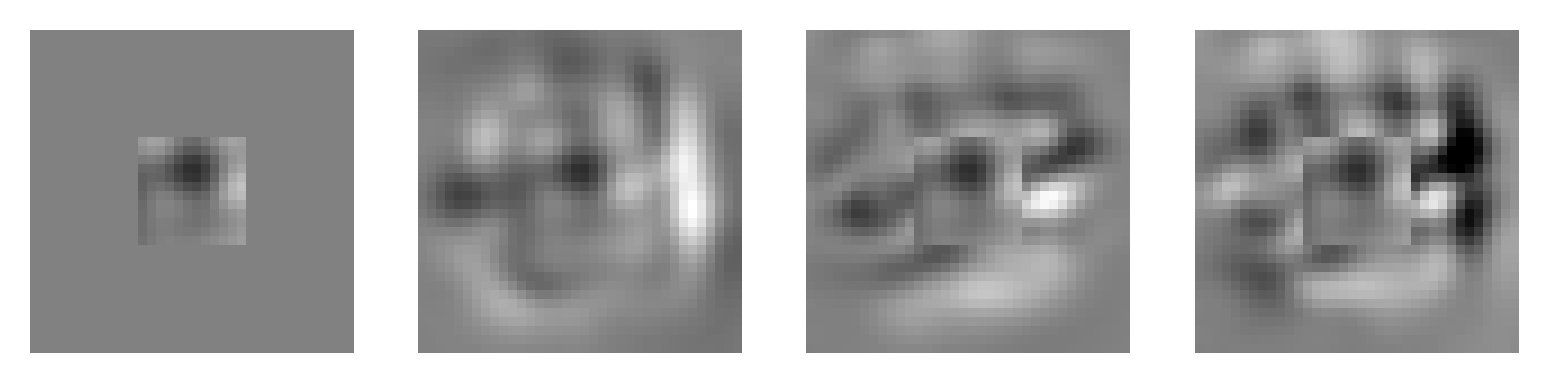

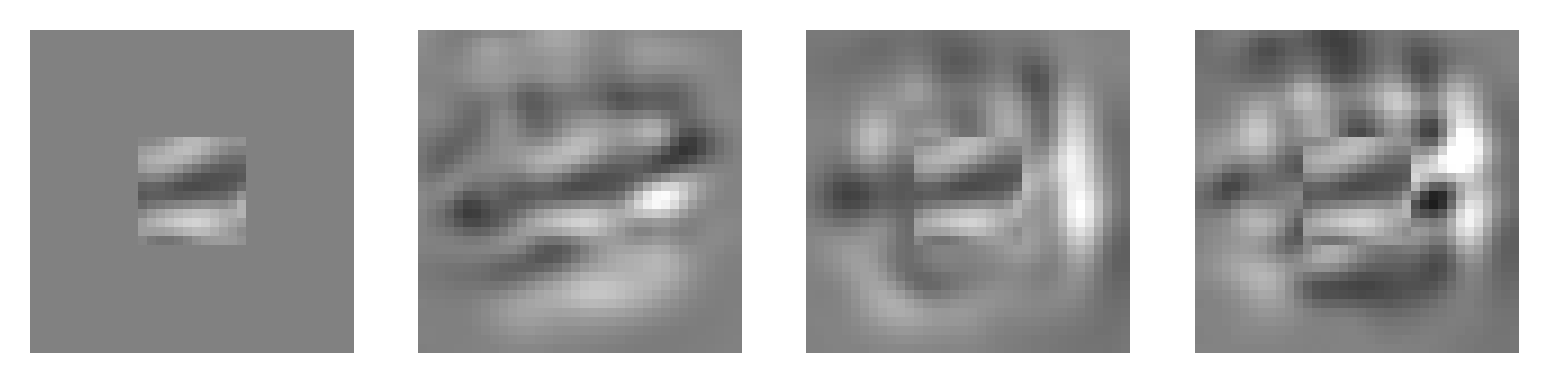

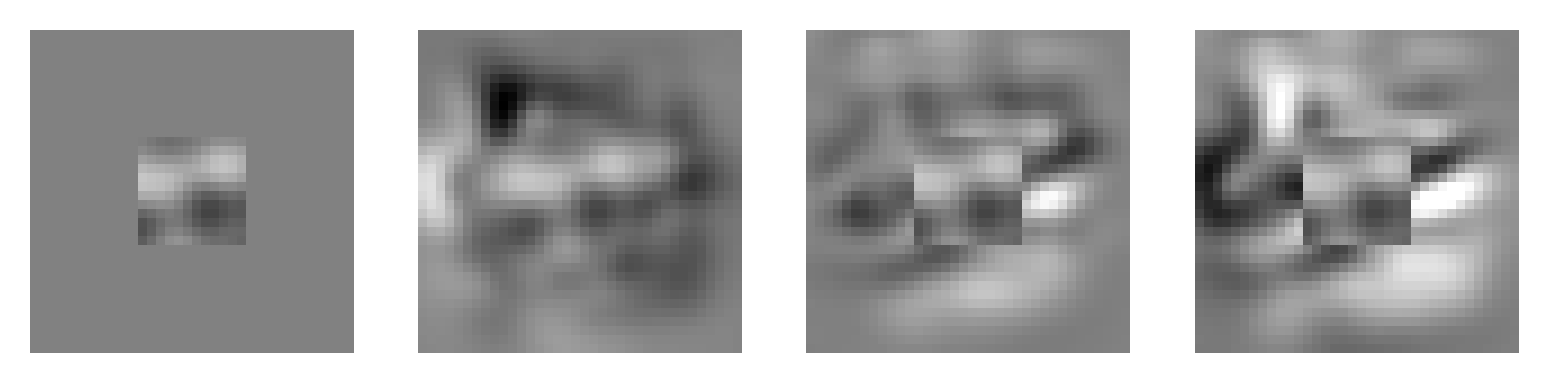

In [12]:
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2):
    fig, axs = plt.subplots(1, 4, dpi=300)
    axs[0].imshow(MEI, cmap="gray", vmin=vmin, vmax=vmax)
    axs[0].axis("off")
    axs[1].imshow(completing_pattern, cmap="gray", vmin=vmin, vmax=vmax)
    axs[1].axis("off")
    axs[2].imshow(disrupting_pattern_1, cmap="gray", vmin=vmin, vmax=vmax)
    axs[2].axis("off")
    axs[3].imshow(disrupting_pattern_2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[3].axis("off")

In [13]:
all_idata = []
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2):
    idata_set = []
    idata = model(
        image=MEI,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=completing_pattern,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_1,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_2,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    all_idata.append(idata_set)
    # break


Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 24 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 16 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 21 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 30 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


...

Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 17 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 27 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 29 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 25 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 15 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


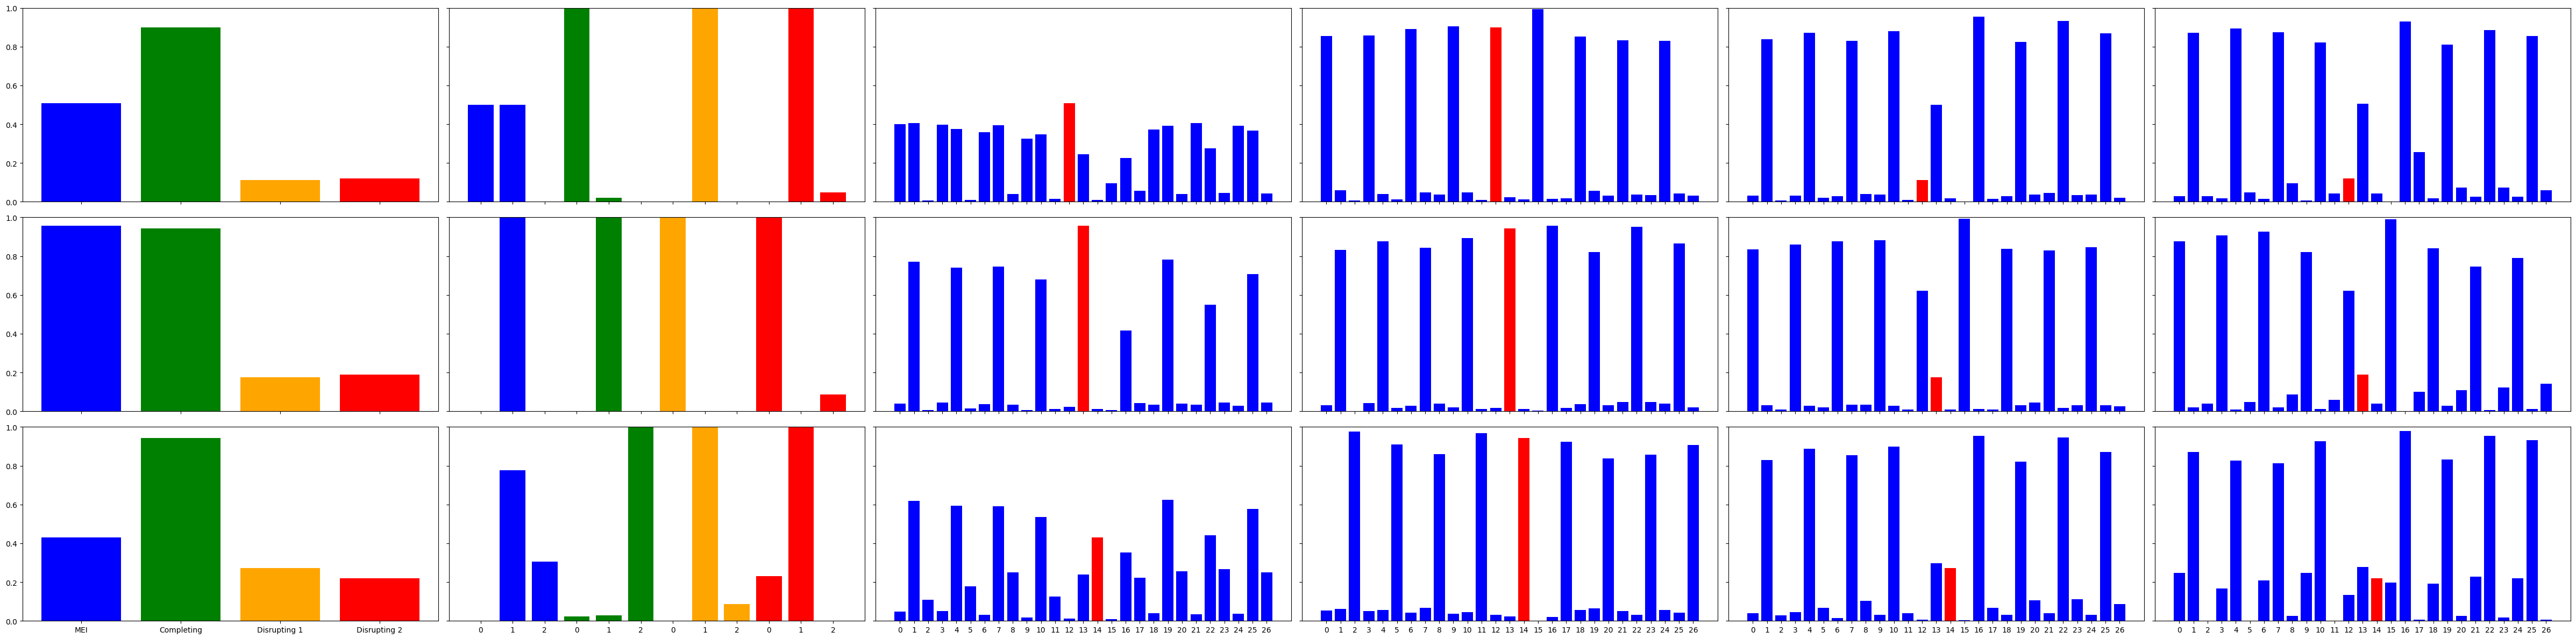

In [14]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

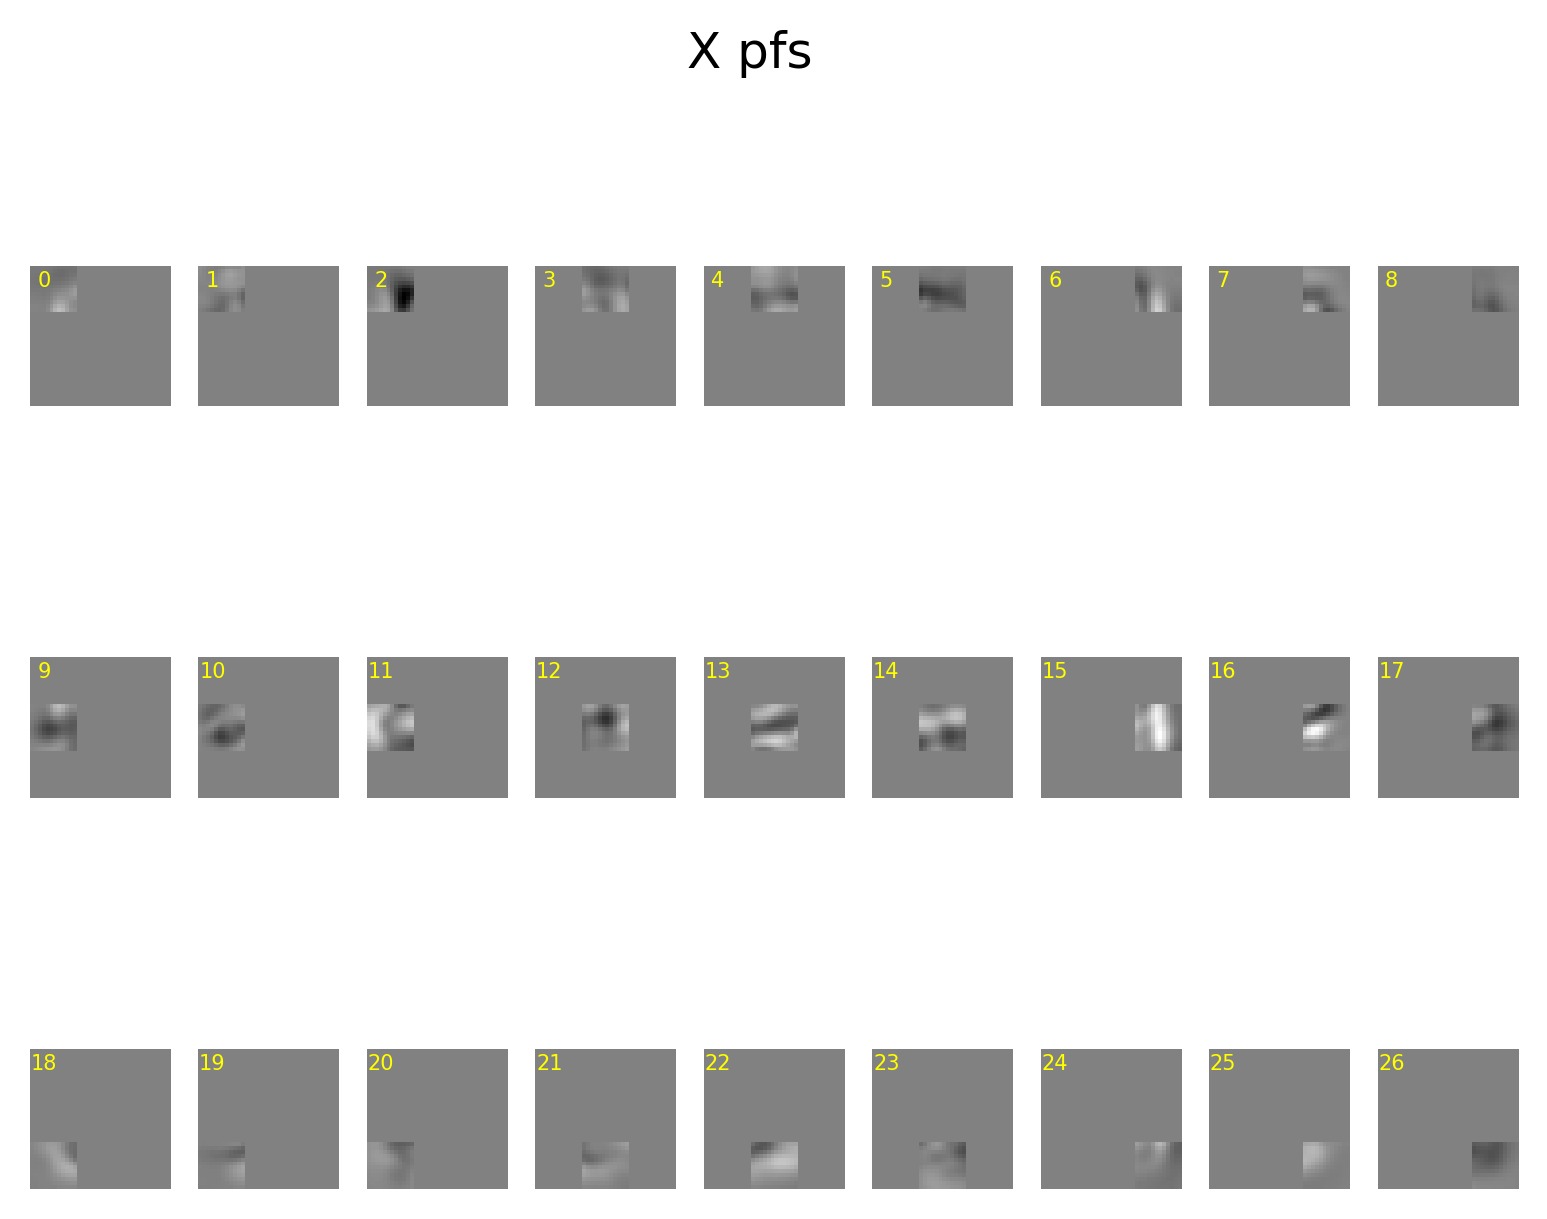

In [15]:
all_patches = model.visualize_learned_X(nrows=x_visual_nrows, ncols=x_visual_ncols)

In [16]:
blank_idata = model(
    image=np.zeros_like(MEIs[0]),
    n_samples=n_draws,
    tune=n_tune,
    chains=n_chains,
    cores=n_cores,
    random_seed=seed
)

Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 13 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [17]:
blank_idata["posterior"]["X"]

<xarray.DataArray 'X' (chain: 4, draw: 300, X_dim_0: 27)>
array([[[0, 0, 0, ..., 0, 1, 1],
        [0, 0, 0, ..., 0, 1, 1],
        [0, 1, 0, ..., 0, 1, 0],
        ...,
        [1, 1, 0, ..., 0, 1, 0],
        [1, 1, 0, ..., 0, 1, 0],
        [1, 1, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 1, 1],
        [0, 0, 0, ..., 0, 1, 1],
        [0, 1, 0, ..., 0, 1, 1],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 0, 1]],

       [[0, 1, 0, ..., 1, 1, 0],
        [0, 1, 0, ..., 0, 1, 0],
        [0, 1, 0, ..., 0, 1, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 1, 0]],

       [[0, 1, 0, ..., 0, 1, 0],
        [0, 1, 0, ..., 0, 1, 0],
        [0, 1, 0, ..., 0, 1, 0],
        ...,
        [0, 0, 0, ..., 0, 1, 0],
        [0, 1, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 0, 0]]])
Coordinates:
  * chain    (chain) int64 0 1 2 3
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 ... 292 293 294 295 296 297 298 299
  * X_dim_0  (X_dim_0) int64 0 1 2 3 4 5 6 7 8 9 ... 18 19 20 21 22 23 24 25 26

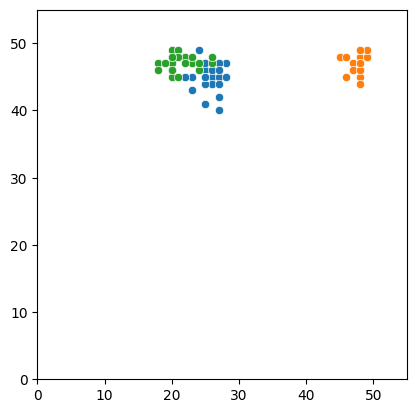

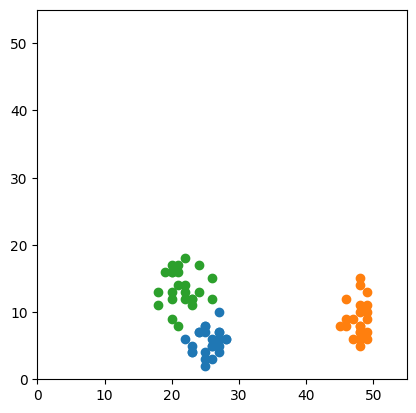

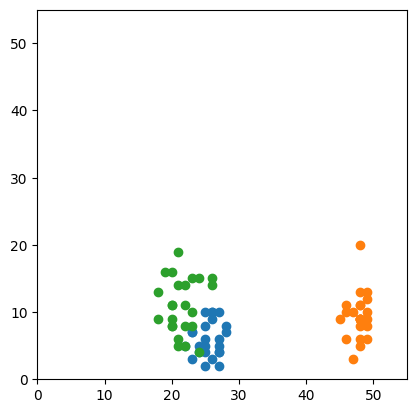

In [18]:
# colors = plt.cm.tab10(range(len(all_idata)))
# fig, axs = plt.subplots(nrows=1, ncols=3, dpi=300, sharey=True, tight_layout=True)
fig_exc, ax_exc = plt.subplots()
fig_dis1, ax_dis1 = plt.subplots()
fig_dis2, ax_dis2 = plt.subplots()
for idx, (idata_set, disrupting_pattern_idx) in enumerate(
    zip(all_idata, disrupting_pattern_indices)
):
    center_x_id = 4 * G_dim + idx

    # idata['posterior']['X'].data.shape = (n_chains, n_samples, n_x_dims)
    mei_firing_rates = (
        idata_set[0].posterior.X.data[:, :, center_x_id].reshape(50, 24).sum(axis=0)
    )
    completing_firing_rates = (
        idata_set[1].posterior.X.data[:, :, center_x_id].reshape(50, 24).sum(axis=0)
    )
    disrupting_1_firing_rates = (
        idata_set[2].posterior.X.data[:, :, center_x_id].reshape(50, 24).sum(axis=0)
    )
    disrupting_2_firing_rates = (
        idata_set[3].posterior.X.data[:, :, center_x_id].reshape(50, 24).sum(axis=0)
    )
    sns.scatterplot(x=mei_firing_rates, y=completing_firing_rates, ax=ax_exc)
    # ax_exc.scatter(mei_firing_rates, completing_firing_rates)
    ax_exc.set_xlim(0, 55)
    ax_exc.set_ylim(0, 55)
    # make square
    ax_exc.set_box_aspect(1)

    ax_dis1.scatter(mei_firing_rates, disrupting_1_firing_rates)
    ax_dis1.set_xlim(0, 55)
    ax_dis1.set_ylim(0, 55)
    # make square
    ax_dis1.set_box_aspect(1)

    ax_dis2.scatter(mei_firing_rates, disrupting_2_firing_rates)
    ax_dis2.set_xlim(0, 55)
    ax_dis2.set_ylim(0, 55)
    # make square
    ax_dis2.set_box_aspect(1)

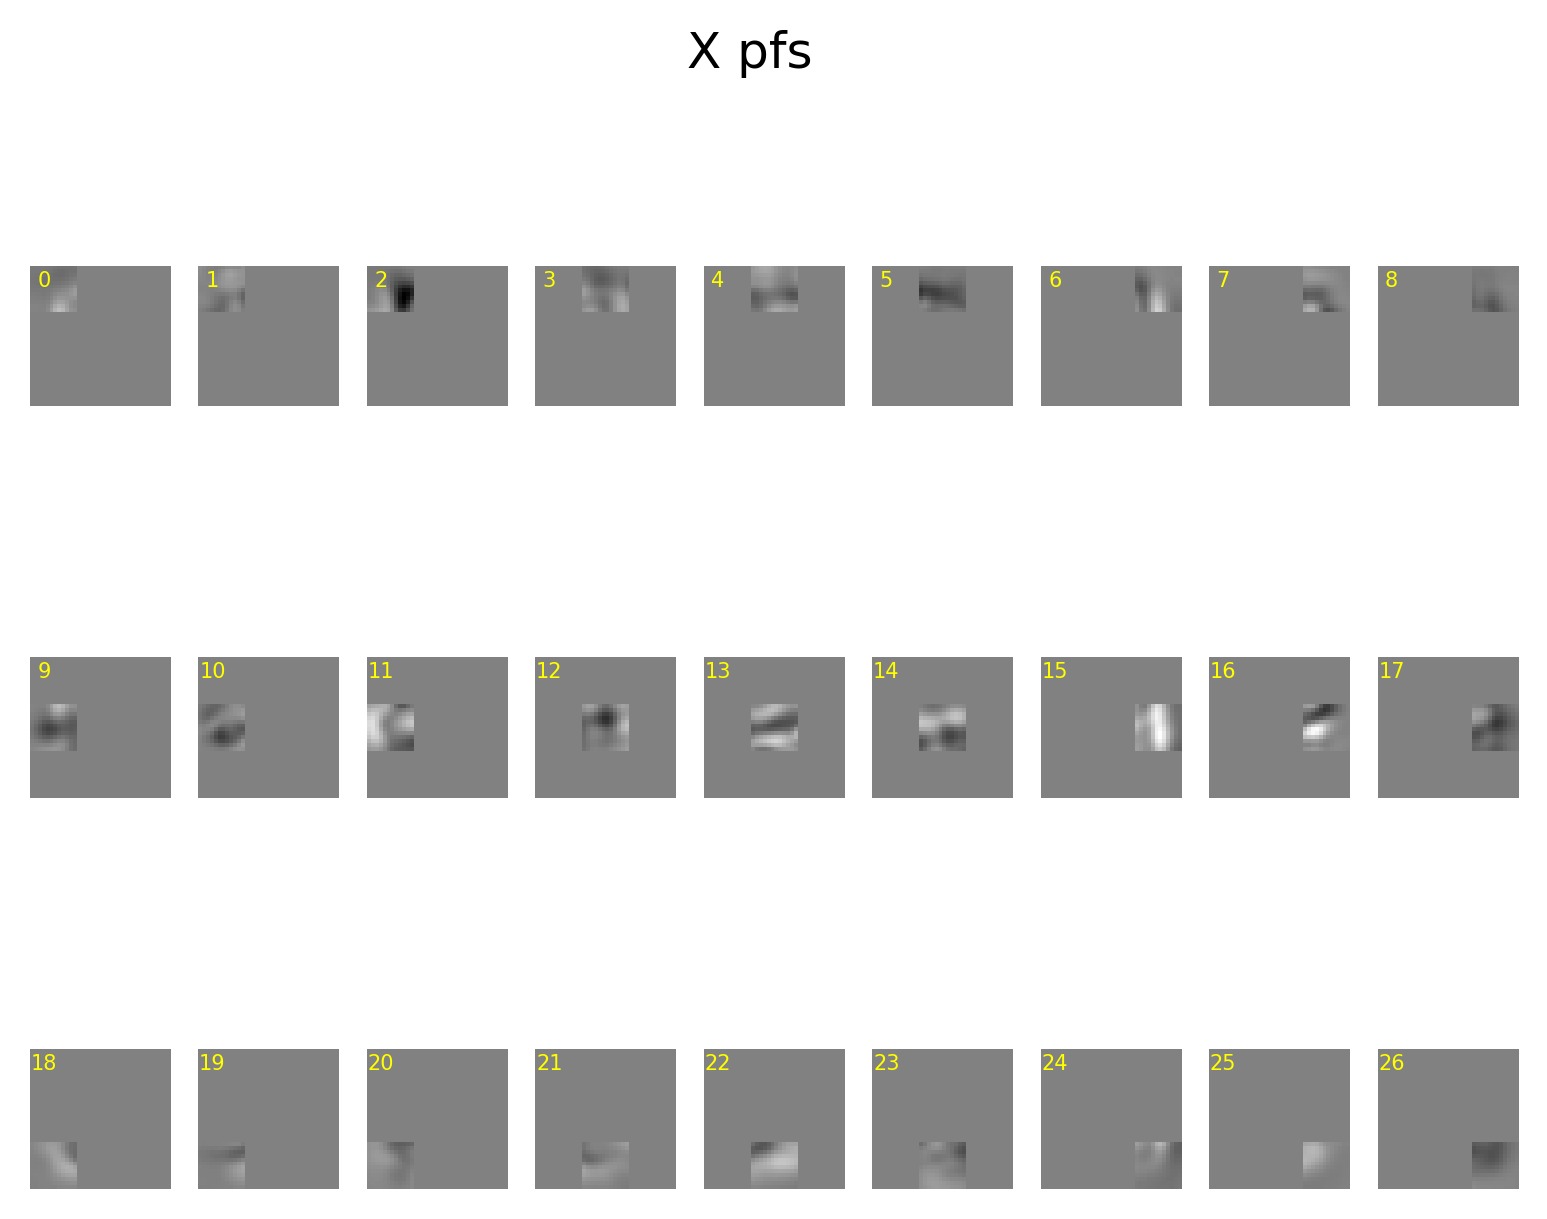

In [19]:
all_patches = model.visualize_learned_X(nrows=x_visual_nrows, ncols=x_visual_ncols)

In [20]:
meis_np = np.array(MEIs)

In [21]:
meis_np.shape

(3, 36, 36)

In [22]:
meis_np - meis_np

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

In [23]:
flat_meis = meis_np.reshape(3, 36 * 36)

In [24]:
flat_meis.shape

(3, 1296)

In [25]:
flat_meis[np.newaxis, :].shape

(1, 3, 1296)

In [26]:
flat_meis[:, np.newaxis].shape

(3, 1, 1296)

In [27]:
l2 = np.sqrt(np.sum((flat_meis[:, np.newaxis] - flat_meis[np.newaxis, :]) ** 2, axis=-1))

In [28]:
l2/36/36

array([[0.        , 0.16654004, 0.18445703],
       [0.16654004, 0.        , 0.21369365],
       [0.18445703, 0.21369365, 0.        ]])

In [29]:
len(MEIs)

3

In [30]:
completing_perc_diff_list

array([ 76.7594108 ,  -1.22057541, 119.37984496])

In [31]:
disrupting_1_perc_diff_list

array([-77.90507365, -81.60418483, -36.62790698])

In [32]:
disrupting_2_perc_diff_list

array([-76.43207856, -80.29642546, -48.8372093 ])

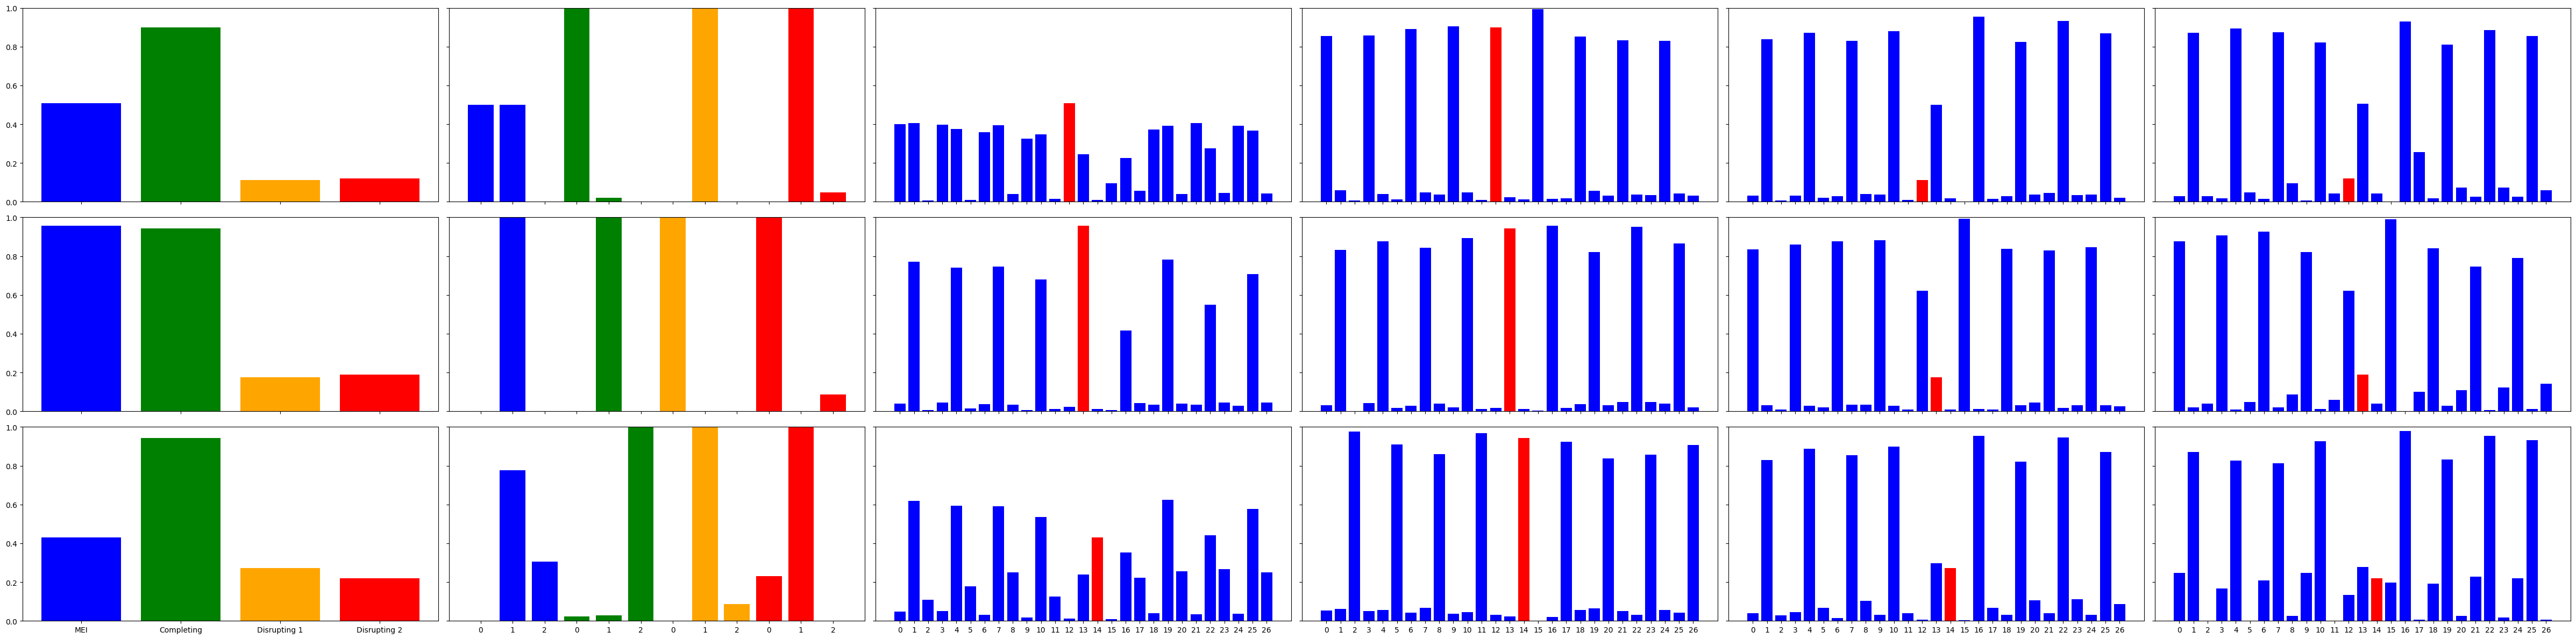

In [33]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

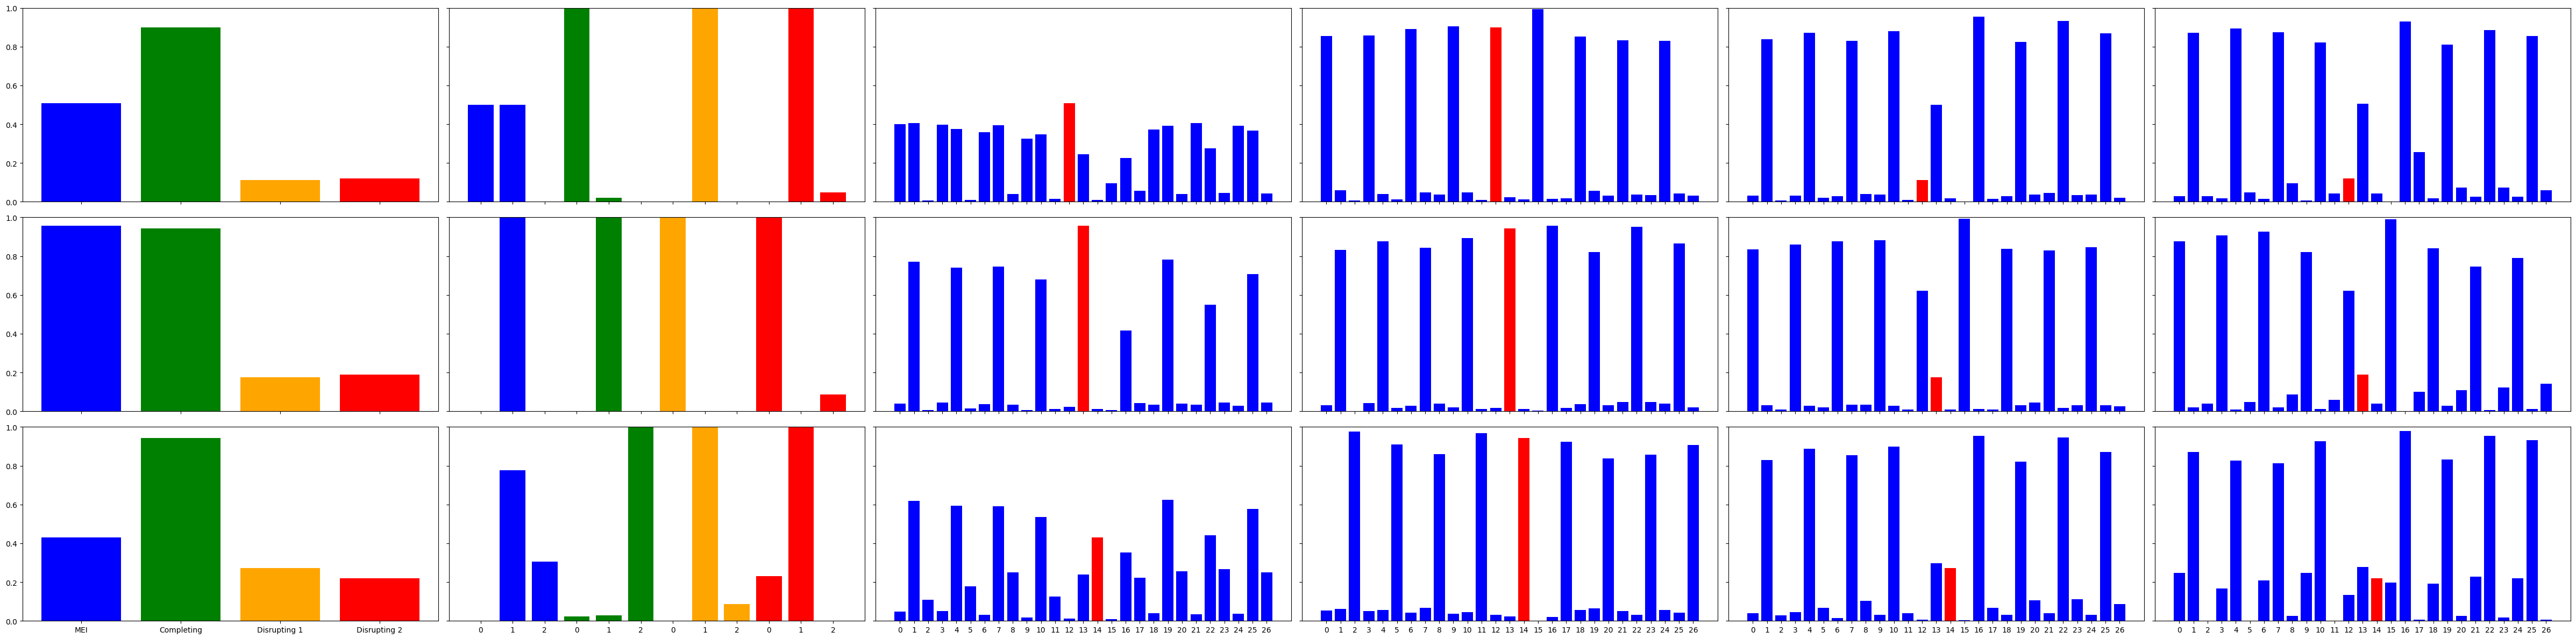

In [34]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [35]:
completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list

(array([ 76.7594108 ,  -1.22057541, 119.37984496]),
 array([-77.90507365, -81.60418483, -36.62790698]),
 array([-76.43207856, -80.29642546, -48.8372093 ]))

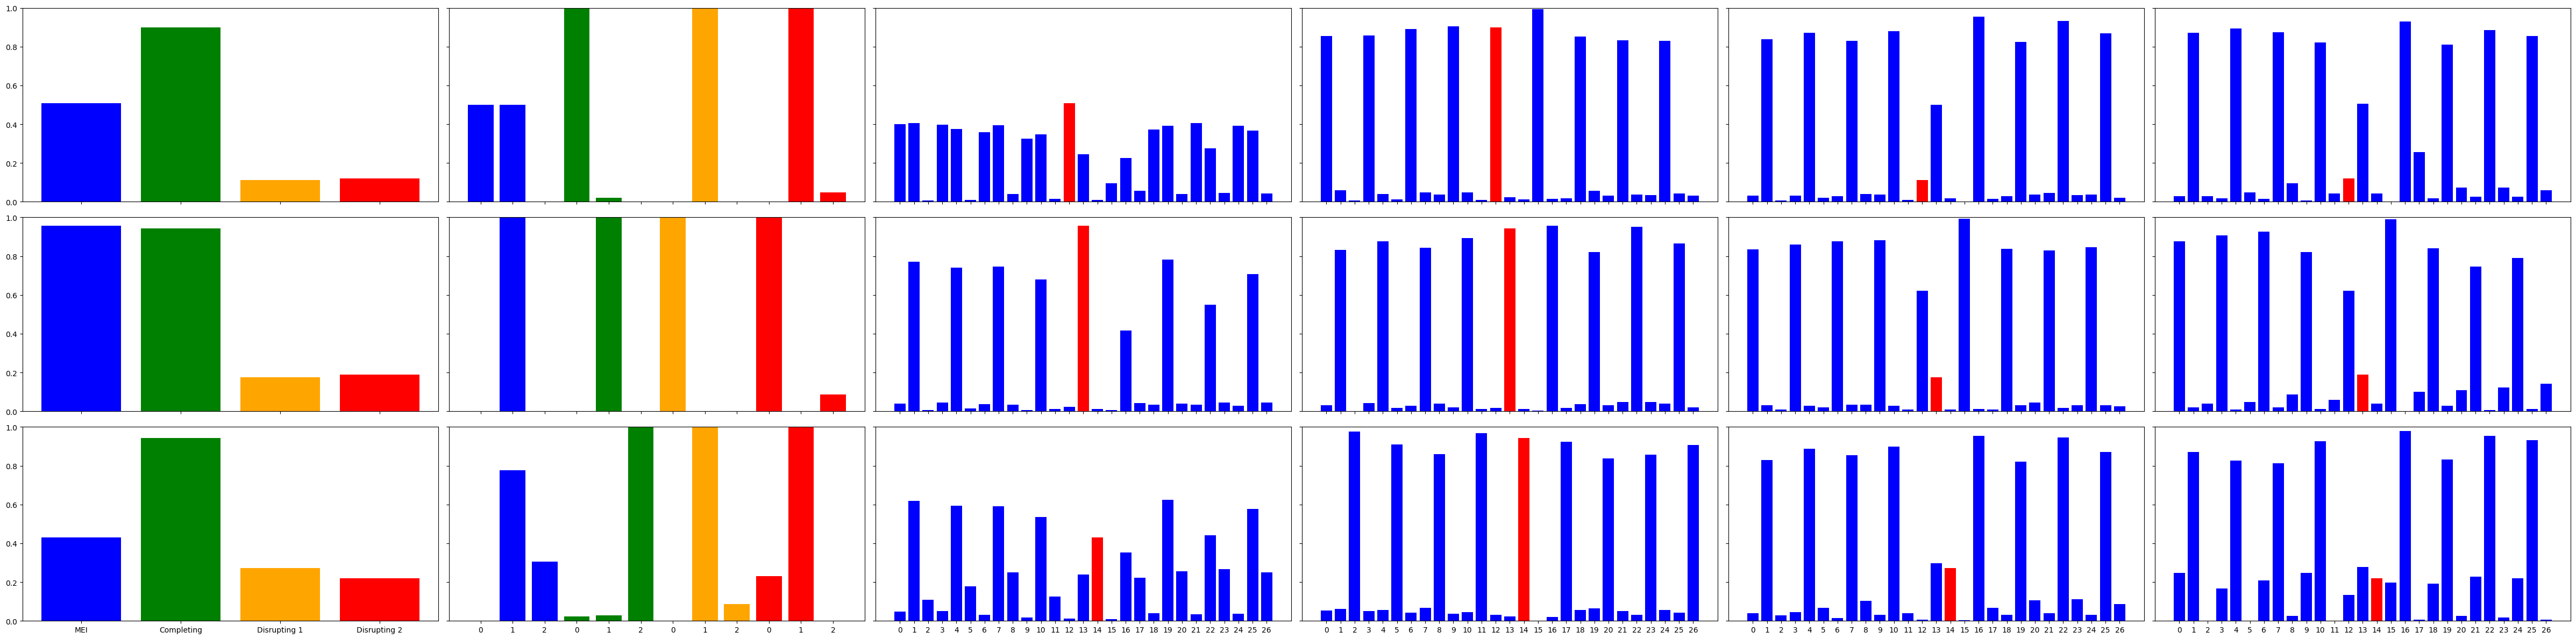

In [36]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [37]:
disrupting_1_perc_diff_list

array([-77.90507365, -81.60418483, -36.62790698])

In [38]:
completing_perc_diff_list

array([ 76.7594108 ,  -1.22057541, 119.37984496])

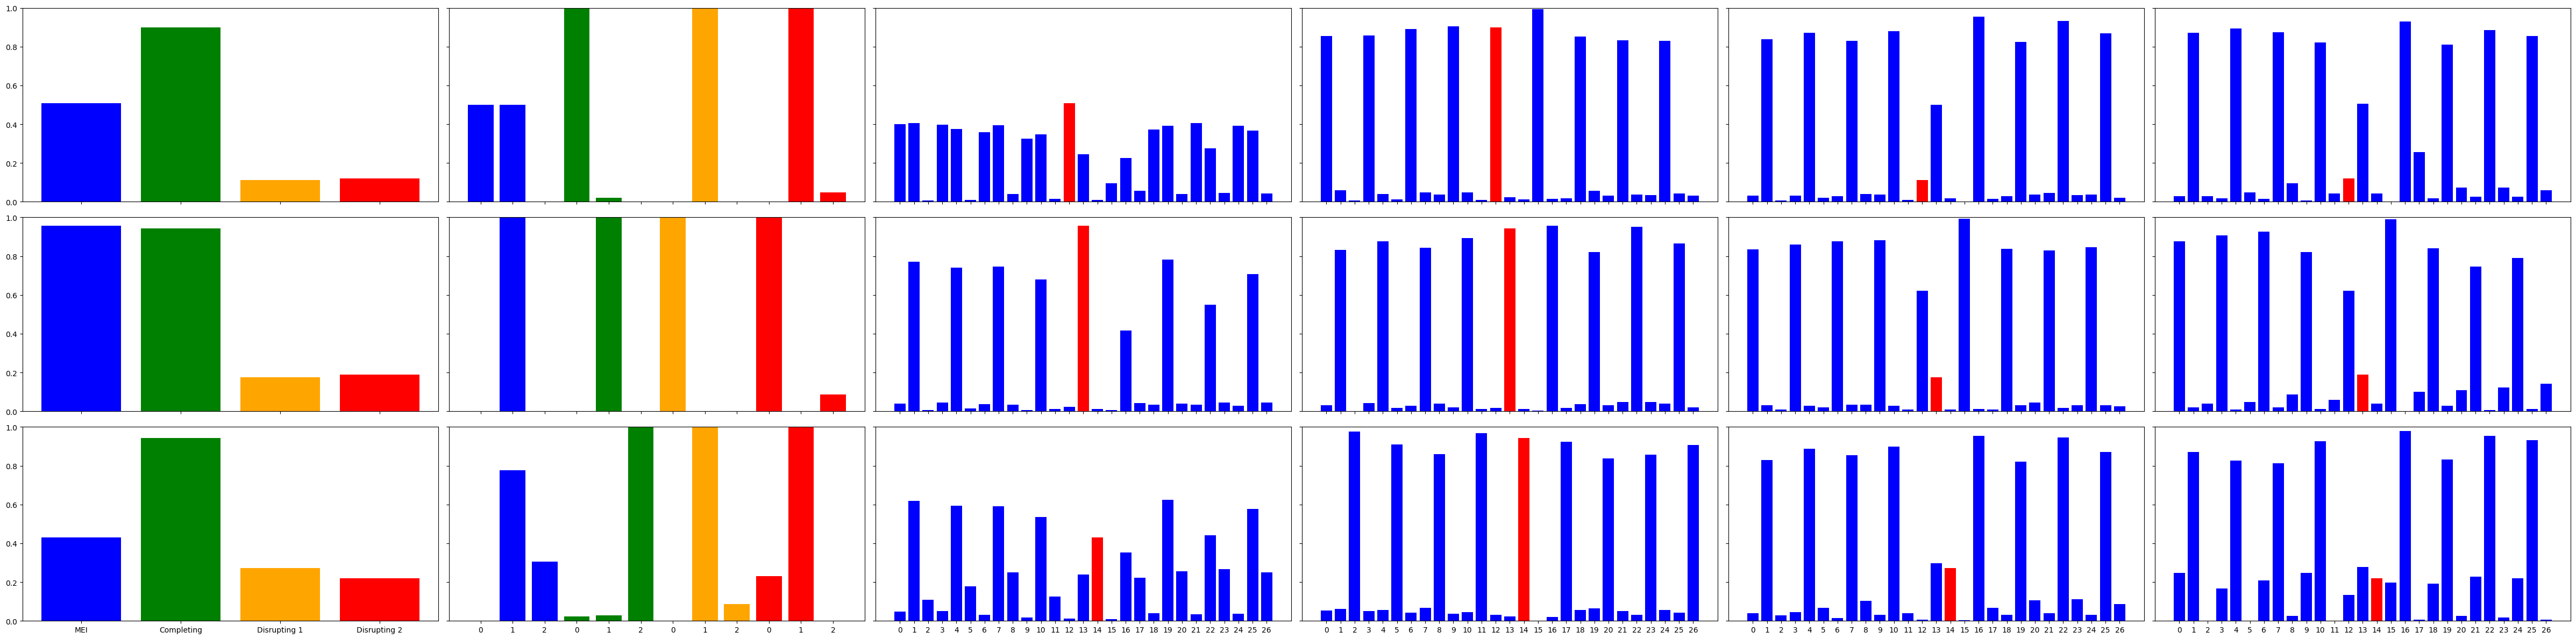

In [39]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [40]:
np.all(all_idata[0][0]['posterior']['X'].data == all_idata[1][0]['posterior']['X'].data)

False

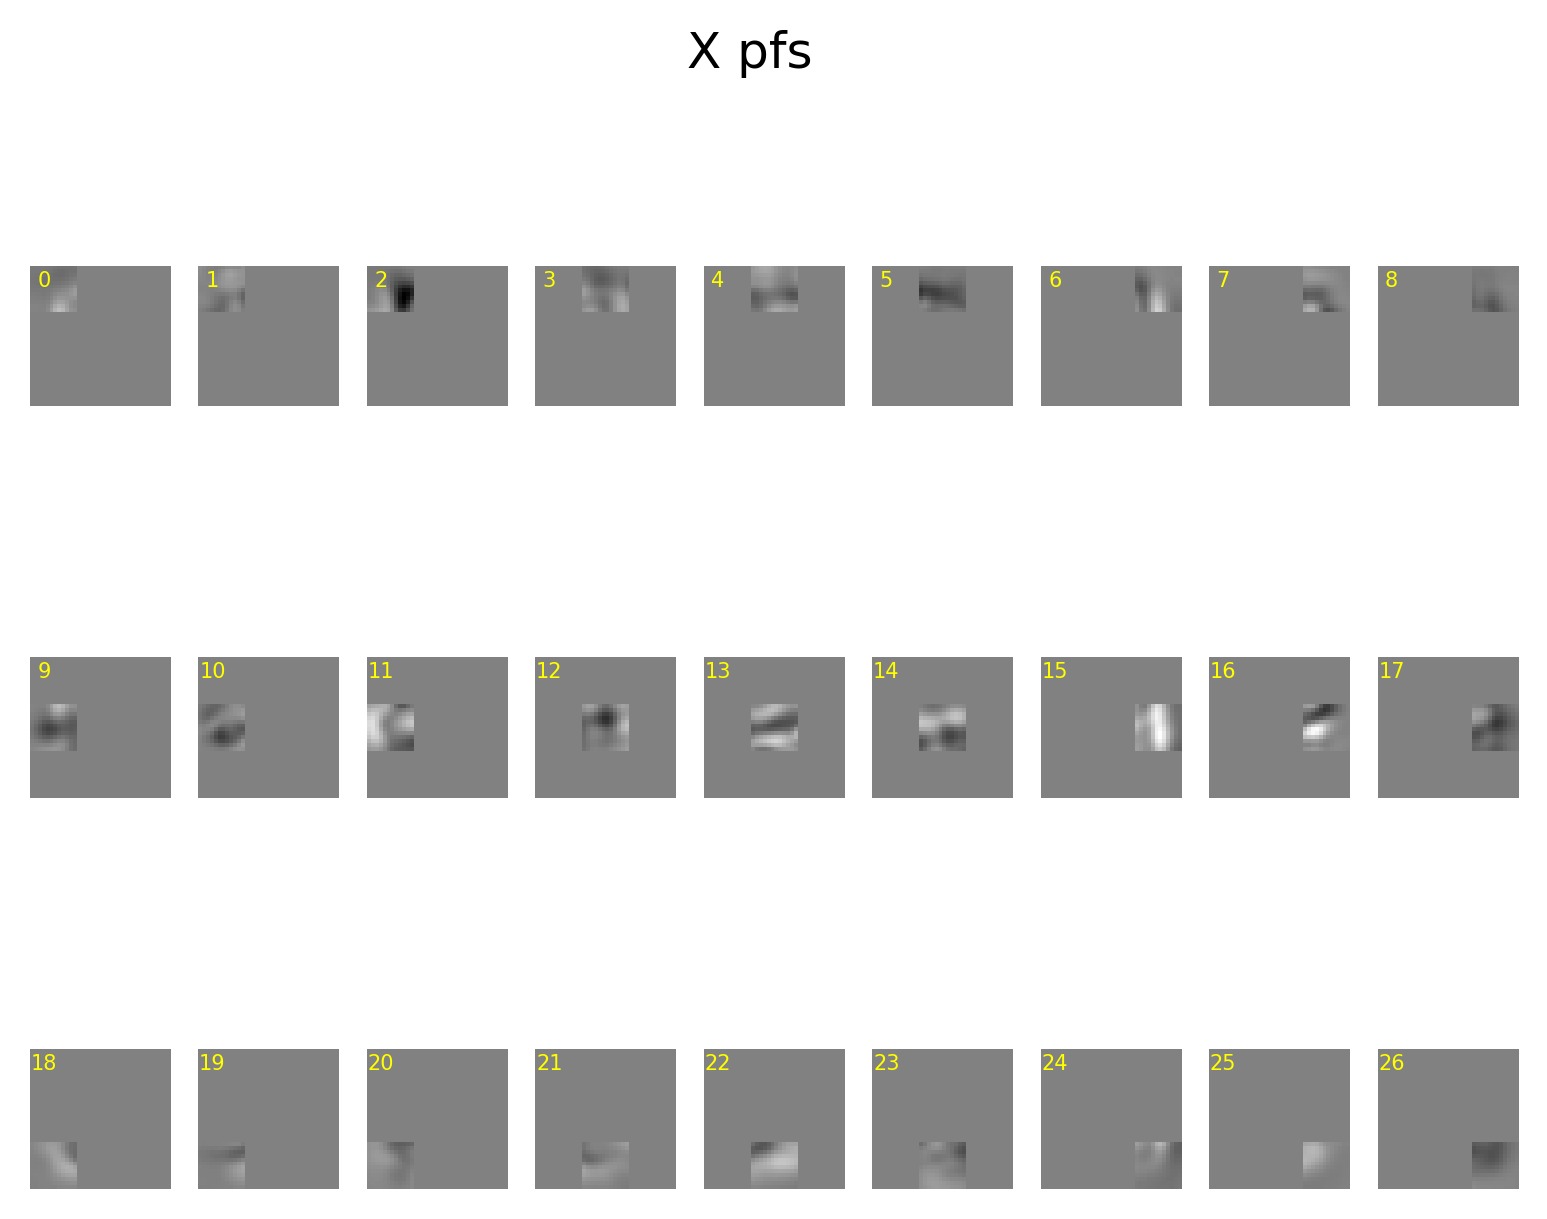

In [41]:
images = model.visualize_learned_X(nrows=x_visual_nrows, ncols=x_visual_ncols)

(-0.5, 35.5, 35.5, -0.5)

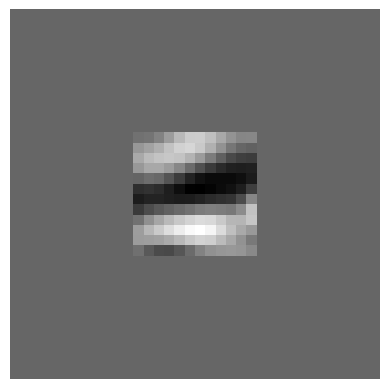

In [42]:
plt.imshow(MEIs[1], cmap="gray")
plt.axis("off")